# 06b - Improved Models (Daily Data, Tuned)

**Improvements over 06:**
1. Hyperparameter tuning with Optuna (TimeSeriesSplit CV)
2. LightGBM added
3. Class weights for imbalance
4. Time-based train/test split

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib
import warnings
warnings.filterwarnings('ignore')
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)

label_names = {0: 'ATM', 1: 'OTM5', 2: 'OTM10'}
print("Imports OK")

Imports OK


## 1. Load and Split

In [2]:
data = pd.read_parquet(PROCESSED / 'daily_modeling_data.parquet')
data['date'] = pd.to_datetime(data['date'])

exclude = ['symbol', 'date', 'year_month', 'best_moneyness', 'best_return', 'label_3', 'year']
feature_cols = [c for c in data.columns if c not in exclude]

unique_dates = data['date'].sort_values().unique()
split_date = unique_dates[int(len(unique_dates) * 0.8)]

X_train = data.loc[data['date'] < split_date, feature_cols].copy()
X_test = data.loc[data['date'] >= split_date, feature_cols].copy()
y_train = data.loc[data['date'] < split_date, 'label_3'].copy()
y_test = data.loc[data['date'] >= split_date, 'label_3'].copy()

med = X_train.median()
X_train = X_train.fillna(med)
X_test = X_test.fillna(med)

cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train)
cw_dict = dict(enumerate(cw))

tscv = TimeSeriesSplit(n_splits=5)

print(f"Split: {pd.Timestamp(split_date).date()}")
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}, Features: {len(feature_cols)}")

Split: 2022-06-14
Train: 21,395, Test: 7,878, Features: 27


## 2. Optuna Tuning

In [3]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 4, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': 'balanced', 'random_state': SEED, 'n_jobs': -1
    }
    scores = cross_val_score(RandomForestClassifier(**params), X_train, y_train, cv=tscv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': SEED, 'use_label_encoder': False, 'eval_metric': 'mlogloss', 'n_jobs': -1
    }
    sw = compute_sample_weight('balanced', y_train)
    scores = []
    for tr_idx, val_idx in tscv.split(X_train):
        m = XGBClassifier(**params)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx], sample_weight=sw[tr_idx])
        scores.append(f1_score(y_train.iloc[val_idx], m.predict(X_train.iloc[val_idx]), average='macro'))
    return np.mean(scores)

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'class_weight': 'balanced', 'random_state': SEED, 'verbose': -1, 'n_jobs': -1
    }
    scores = cross_val_score(LGBMClassifier(**params), X_train, y_train, cv=tscv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

print("Tuning objectives defined")

Tuning objectives defined


In [4]:
study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)
print(f"RF best CV F1: {study_rf.best_value:.4f}")


  0%|          | 0/20 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.390933:   0%|          | 0/20 [00:03<?, ?it/s]


Best trial: 0. Best value: 0.390933:   5%|▌         | 1/20 [00:03<01:15,  3.95s/it]


Best trial: 0. Best value: 0.390933:   5%|▌         | 1/20 [00:09<01:15,  3.95s/it]


Best trial: 0. Best value: 0.390933:  10%|█         | 2/20 [00:09<01:25,  4.74s/it]

...


Best trial: 10. Best value: 0.398895:  95%|█████████▌| 19/20 [01:37<00:03,  3.34s/it]


Best trial: 10. Best value: 0.398895:  95%|█████████▌| 19/20 [01:39<00:03,  3.34s/it]


Best trial: 10. Best value: 0.398895: 100%|██████████| 20/20 [01:39<00:00,  2.98s/it]


Best trial: 10. Best value: 0.398895: 100%|██████████| 20/20 [01:39<00:00,  4.97s/it]

RF best CV F1: 0.3989


In [5]:
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)
print(f"XGB best CV F1: {study_xgb.best_value:.4f}")


  0%|          | 0/20 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.360491:   0%|          | 0/20 [00:04<?, ?it/s]


Best trial: 0. Best value: 0.360491:   5%|▌         | 1/20 [00:04<01:31,  4.80s/it]


Best trial: 0. Best value: 0.360491:   5%|▌         | 1/20 [00:10<01:31,  4.80s/it]


Best trial: 0. Best value: 0.360491:  10%|█         | 2/20 [00:10<01:37,  5.41s/it]

...


Best trial: 10. Best value: 0.375945:  95%|█████████▌| 19/20 [01:19<00:04,  4.62s/it]


Best trial: 10. Best value: 0.375945:  95%|█████████▌| 19/20 [01:22<00:04,  4.62s/it]


Best trial: 10. Best value: 0.375945: 100%|██████████| 20/20 [01:22<00:00,  4.14s/it]


Best trial: 10. Best value: 0.375945: 100%|██████████| 20/20 [01:22<00:00,  4.13s/it]

XGB best CV F1: 0.3759


In [6]:
study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)
print(f"LGBM best CV F1: {study_lgbm.best_value:.4f}")


  0%|          | 0/20 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.392826:   0%|          | 0/20 [00:29<?, ?it/s]


Best trial: 0. Best value: 0.392826:   5%|▌         | 1/20 [00:29<09:22, 29.62s/it]


Best trial: 0. Best value: 0.392826:   5%|▌         | 1/20 [00:45<09:22, 29.62s/it]


Best trial: 0. Best value: 0.392826:  10%|█         | 2/20 [00:45<06:30, 21.72s/it]

...


Best trial: 15. Best value: 0.400426:  95%|█████████▌| 19/20 [06:36<00:30, 30.43s/it]


Best trial: 15. Best value: 0.400426:  95%|█████████▌| 19/20 [07:09<00:30, 30.43s/it]


Best trial: 15. Best value: 0.400426: 100%|██████████| 20/20 [07:09<00:00, 31.00s/it]


Best trial: 15. Best value: 0.400426: 100%|██████████| 20/20 [07:09<00:00, 21.46s/it]

LGBM best CV F1: 0.4004


## 3. Evaluate on Test Set

In [7]:
rf_t = RandomForestClassifier(**study_rf.best_params, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_t.fit(X_train, y_train)
p_rf = rf_t.predict(X_test)

xgb_t = XGBClassifier(**study_xgb.best_params, random_state=SEED, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
xgb_t.fit(X_train, y_train, sample_weight=compute_sample_weight('balanced', y_train))
p_xgb = xgb_t.predict(X_test)

lgbm_t = LGBMClassifier(**study_lgbm.best_params, class_weight='balanced', random_state=SEED, verbose=-1, n_jobs=-1)
lgbm_t.fit(X_train, y_train)
p_lgbm = lgbm_t.predict(X_test)

results = {}
for name, preds in [('RF', p_rf), ('XGB', p_xgb), ('LGBM', p_lgbm)]:
    results[name] = {'Accuracy': accuracy_score(y_test, preds), 'Macro F1': f1_score(y_test, preds, average='macro')}
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}, F1={results[name]['Macro F1']:.4f}")

print()
for name, preds in [('RF', p_rf), ('XGB', p_xgb), ('LGBM', p_lgbm)]:
    print(f"\n{name}:")
    print(classification_report(y_test, preds, target_names=['ATM','OTM5','OTM10']))

RF: Acc=0.4995, F1=0.3377
XGB: Acc=0.5036, F1=0.3420
LGBM: Acc=0.4835, F1=0.3486


RF:
              precision    recall  f1-score   support

         ATM       0.55      0.76      0.64      4119
        OTM5       0.06      0.02      0.03      1099
       OTM10       0.43      0.29      0.35      2660

    accuracy                           0.50      7878
   macro avg       0.34      0.36      0.34      7878
weighted avg       0.44      0.50      0.45      7878


XGB:
              precision    recall  f1-score   support

         ATM       0.56      0.82      0.66      4119
        OTM5       0.11      0.08      0.09      1099
       OTM10       0.47      0.19      0.27      2660

    accuracy                           0.50      7878
   macro avg       0.38      0.36      0.34      7878
weighted avg       0.46      0.50      0.45      7878


LGBM:
              precision    recall  f1-score   support

         ATM       0.56      0.77      0.65      4119
        OTM5       0.16      

## 4. Confusion Matrices

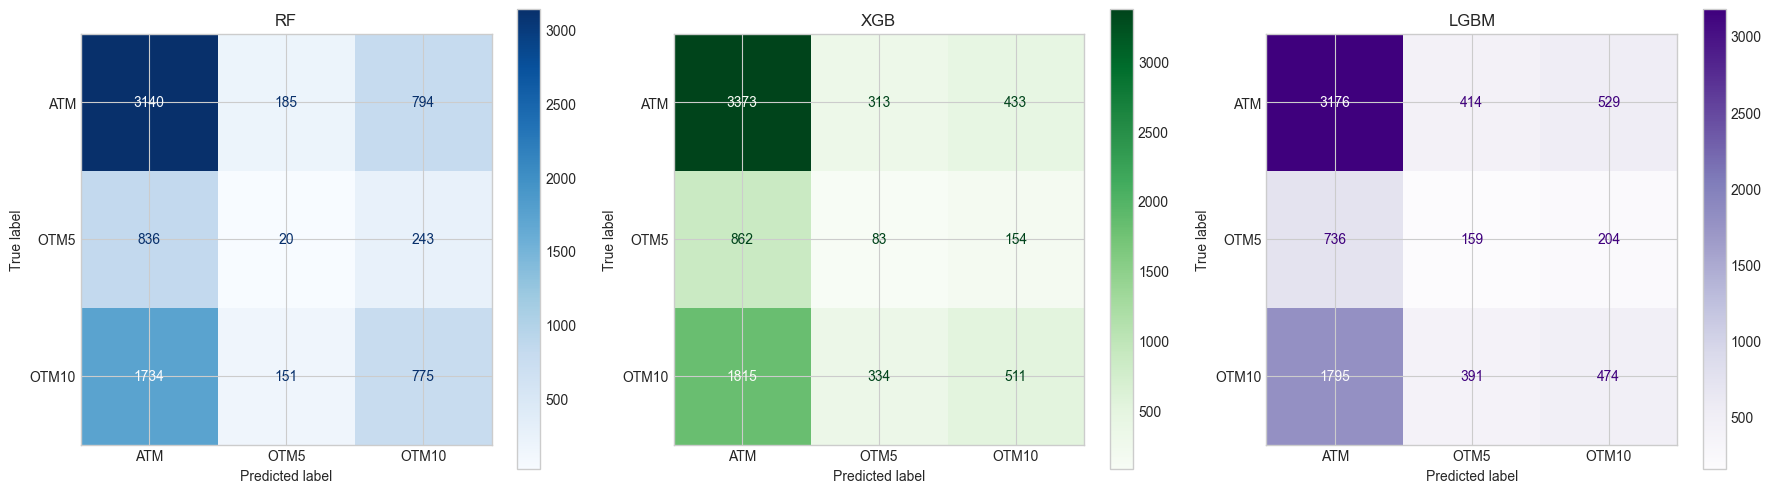

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds, cmap) in zip(axes, [('RF',p_rf,'Blues'),('XGB',p_xgb,'Greens'),('LGBM',p_lgbm,'Purples')]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds), display_labels=['ATM','OTM5','OTM10']).plot(ax=ax, cmap=cmap, values_format='d')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('../reports/figures/improved_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance

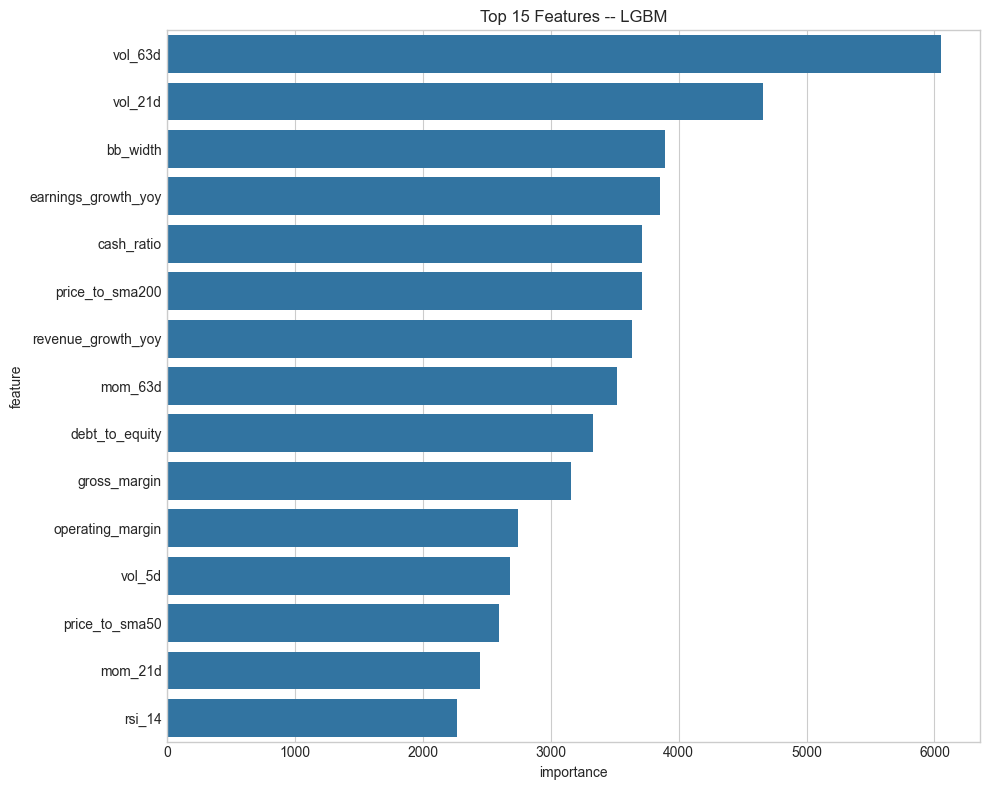

            feature  importance
            vol_63d        6053
            vol_21d        4659
           bb_width        3890
earnings_growth_yoy        3852
         cash_ratio        3716
    price_to_sma200        3711
 revenue_growth_yoy        3633
            mom_63d        3521
     debt_to_equity        3333
       gross_margin        3156
   operating_margin        2741
             vol_5d        2682
     price_to_sma50        2595
            mom_21d        2450
             rsi_14        2269


In [9]:
best_name = max(results, key=lambda k: results[k]['Macro F1'])
best_model = {'RF': rf_t, 'XGB': xgb_t, 'LGBM': lgbm_t}[best_name]
imp = pd.DataFrame({'feature': feature_cols, 'importance': best_model.feature_importances_}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=imp.head(15), x='importance', y='feature', ax=ax)
ax.set_title(f'Top 15 Features -- {best_name}')
plt.tight_layout()
plt.savefig('../reports/figures/improved_feature_importance.png', dpi=150)
plt.show()
print(imp.head(15).to_string(index=False))

## 6. Save

In [ ]:
res_df = pd.DataFrame(results).T.reset_index().rename(columns={'index':'Model'})
res_df.to_csv(PROCESSED / 'improved_results.csv', index=False)
joblib.dump(rf_t, MODELS / 'rf_tuned_3class.joblib')
joblib.dump(xgb_t, MODELS / 'xgb_tuned_3class.joblib')
joblib.dump(lgbm_t, MODELS / 'lgbm_tuned_3class.joblib')
metadata = {'feature_cols': feature_cols, 'split_date': str(pd.Timestamp(split_date).date()),
            'best_model': best_name, 'approach': 'daily data, time-split, class weights, 3-class'}
with open(MODELS / 'improved_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Best model: {best_name} (F1={results[best_name]['Macro F1']:.4f})")

Best model: LGBM (F1=0.3486)
All saved.
